### This notebooks describe basic tutorial of Doranet 
(https://github.com/wsprague-nu/doranet/tree/main/docs/source/tutorials)

In [7]:
import doranet as dn
from rdkit import Chem

In [8]:
engine = dn.create_engine()

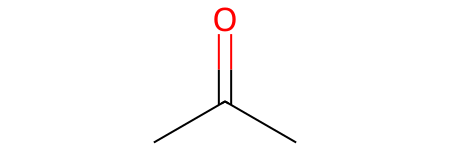

In [9]:
acetone = engine.mol.rdkit("CC(=O)C")
acetone.smiles
mol = Chem.MolFromSmiles(acetone.smiles)
mol

#### Define some new molecules for test

In [10]:
water = engine.mol.rdkit("O")
ethanol = engine.mol.rdkit("CCO")
acetone = engine.mol.rdkit("CC(C)=O")
butanone = engine.mol.rdkit("CCC(C)=O")
methyl_butanoate = engine.mol.rdkit("CCCC(=O)OC")
delta_valerolactone = engine.mol.rdkit("O=C1CCCCO1")
hydroxyvaleric_acid = engine.mol.rdkit("O=C(O)CCCCO")

#### Define type of reactions

In [11]:
### aldol condensation reaction via engine
aldol_condensation = engine.op.rdkit("[O&+0:1]=[C&+0:2]-[C&+0;H2,H3:3].[C&+0:4]=[O&+0:5]>>[*:1]=[*:2]-[*:3]=[*:4].[*:5]")
### Ring-Forming Reactions in RDKit
esterification = engine.op.rdkit("[O&+0:1]=[C&+0:2]-[O&+0&H1:3].[O&+0&H1:4]>>[*:1]=[*:2]-[*:4].[*:3]")
### Intramolecular esterification
esterification_intra = engine.op.rdkit("([O&+0:1]=[C&+0:2]-[O&+0&H1:3].[O&+0&H1:4])>>[*:1]=[*:2]-[*:4].[*:3]")
### Ring-Breaking Reactions in RDKit
ester_hydrolysis_incorrect = engine.op.rdkit("[O&+0:1]=[C&+0:2]-[O&+0&H0:3].[O&+0&H2:4]>>[*:1]=[*:2]-[*:4].[*:3]")
ester_hydrolysis_nonring = engine.op.rdkit("[O&+0:1]=[C&+0:2]-&!@[O&+0&H0:3].[O&+0&H2:4]>>[*:1]=[*:2]-[*:4].[*:3]")
ester_hydrolysis_ring = engine.op.rdkit("[O&+0:1]=[C&+0:2]-&@[O&+0&H0:3].[O&+0&H2:4]>>([*:1]=[*:2]-[*:4].[*:3])")

In [12]:
aldol_condensation(acetone,acetone)

((MolDatBasic('CC(=O)C=C(C)C'), MolDatBasic('O')),
 (MolDatBasic('CC(=O)C=C(C)C'), MolDatBasic('O')))

In [13]:
esterification(hydroxyvaleric_acid,ethanol)

((MolDatBasic('CCOC(=O)CCCCO'), MolDatBasic('O')),)

In [14]:
esterification_intra(hydroxyvaleric_acid)

((MolDatBasic('O=C1CCCCO1'), MolDatBasic('O')),)

In [15]:
ester_hydrolysis_incorrect(methyl_butanoate,water)

((MolDatBasic('CCCC(=O)O'), MolDatBasic('CO')),)

In [16]:
ester_hydrolysis_incorrect(delta_valerolactone,water)

((MolDatBasic('CCCCC(=O)O'), MolDatBasic('CCCCO')),)

In [17]:
ester_hydrolysis_nonring(methyl_butanoate,water)

((MolDatBasic('CCCC(=O)O'), MolDatBasic('CO')),)

In [18]:
ester_hydrolysis_nonring(delta_valerolactone,water)

()

In [19]:
ester_hydrolysis_ring(delta_valerolactone,water)

((MolDatBasic('O=C(O)CCCCO'),),)

#### Creating a Basic reaction Network

In [20]:
network = engine.new_network()

In [21]:
water_i = network.add_mol(water)
water_i

0

In [22]:
delta_valerolactone_i = network.add_mol(delta_valerolactone)
delta_valerolactone_i

1

In [23]:
hydroxyvaleric_acid = ester_hydrolysis_ring(delta_valerolactone,water)[0][0]
hydroxyvaleric_acid

MolDatBasic('O=C(O)CCCCO')

In [24]:
water_i = network.mols.i(water.uid)
delta_valerolactone_i = network.mols.i(delta_valerolactone.uid)
ester_hydrolysis_ring_i = network.ops.i(ester_hydrolysis_ring.uid)

hydroxyvaleric_acid = ester_hydrolysis_ring(delta_valerolactone,water)[0][0]
hydroxyvaleric_acid_i = network.add_mol(hydroxyvaleric_acid)

reaction_i = network.add_rxn(
    operator=ester_hydrolysis_ring_i,
    reactants=(delta_valerolactone_i, water_i),
    products=(hydroxyvaleric_acid_i,),
)

KeyError: '[O&+0:1]=[C&+0:2]-&@[O&+0&H0:3].[O&+0&H2:4]>>([*:1]=[*:2]-[*:4].[*:3])'

In [26]:
import sys
from pathlib import Path

# Add the local doranet_ycMOD to the path (before pip-installed doranet)
DORANET_YCMOD_PATH = Path(__file__).parent.parent
sys.path.insert(0, str(DORANET_YCMOD_PATH))

import doranet.modules.enzymatic as enzymatic
import doranet.modules.synthetic as synthetic
import doranet.modules.post_processing as post_processing

user_starters = {'C1=C(C(=CC=O)OC1=O)N'}

user_helpers = {'O','O=O','[H][H]','O=C=O','C=O','[C-]#[O+]','Br','[Br][Br]','CO',
                'C=C','O=S(O)O','N','O=S(=O)(O)O','O=NO','N#N','O=[N+]([O-])O','NO',
                'C#N','S','O=S=O','N#CO'}

user_target = {'OC1=CC=CC=C1'}        

job_name = "test_enzymatic"

forward_network = enzymatic.generate_network(
    job_name = job_name,
    starters = user_starters,
    gen = 1,
    direction = "forward",
    ruleset = "JN3604IMT")

# forward_network = synthetic.generate_network(
#     job_name = job_name,
#     starters = user_starters,
#     helpers = user_helpers,
#     gen = 1,
#     direction = "forward",
#     ruleset = "JN3604IMT"
# )

for mol in forward_network.mols:
    print(mol.uid)

post_processing.one_step(
    networks = {
        forward_network,
        },
    total_generations = 1,
    starters = user_starters,
    helpers = user_helpers,
    target = user_target,
    job_name = job_name,
    )

TypeError: generate_network() got an unexpected keyword argument 'ruleset'